In [3]:
#! /usr/bin/env python3
import numpy as np
import corner
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

In [4]:
h5=h5py.File(f'redo_emcee_dryadiab_depletedNH3_FabianoLD_101_parallel_10000.h5', 'r') 

chain = h5['mcmc']['chain'][:,:,:]
[nstep,nwalk,ndim]=chain.shape
print([nstep,nwalk,ndim])
h5.close()
chain[:, :, ndim-1]*=1E-5  ## pa -> bar
labels=["qNH3 [ppm]", "Temperature [K]", "RH_max_NH3","adlnNH3dlnP","Pmax [bar]"]

[10000, 12, 5]


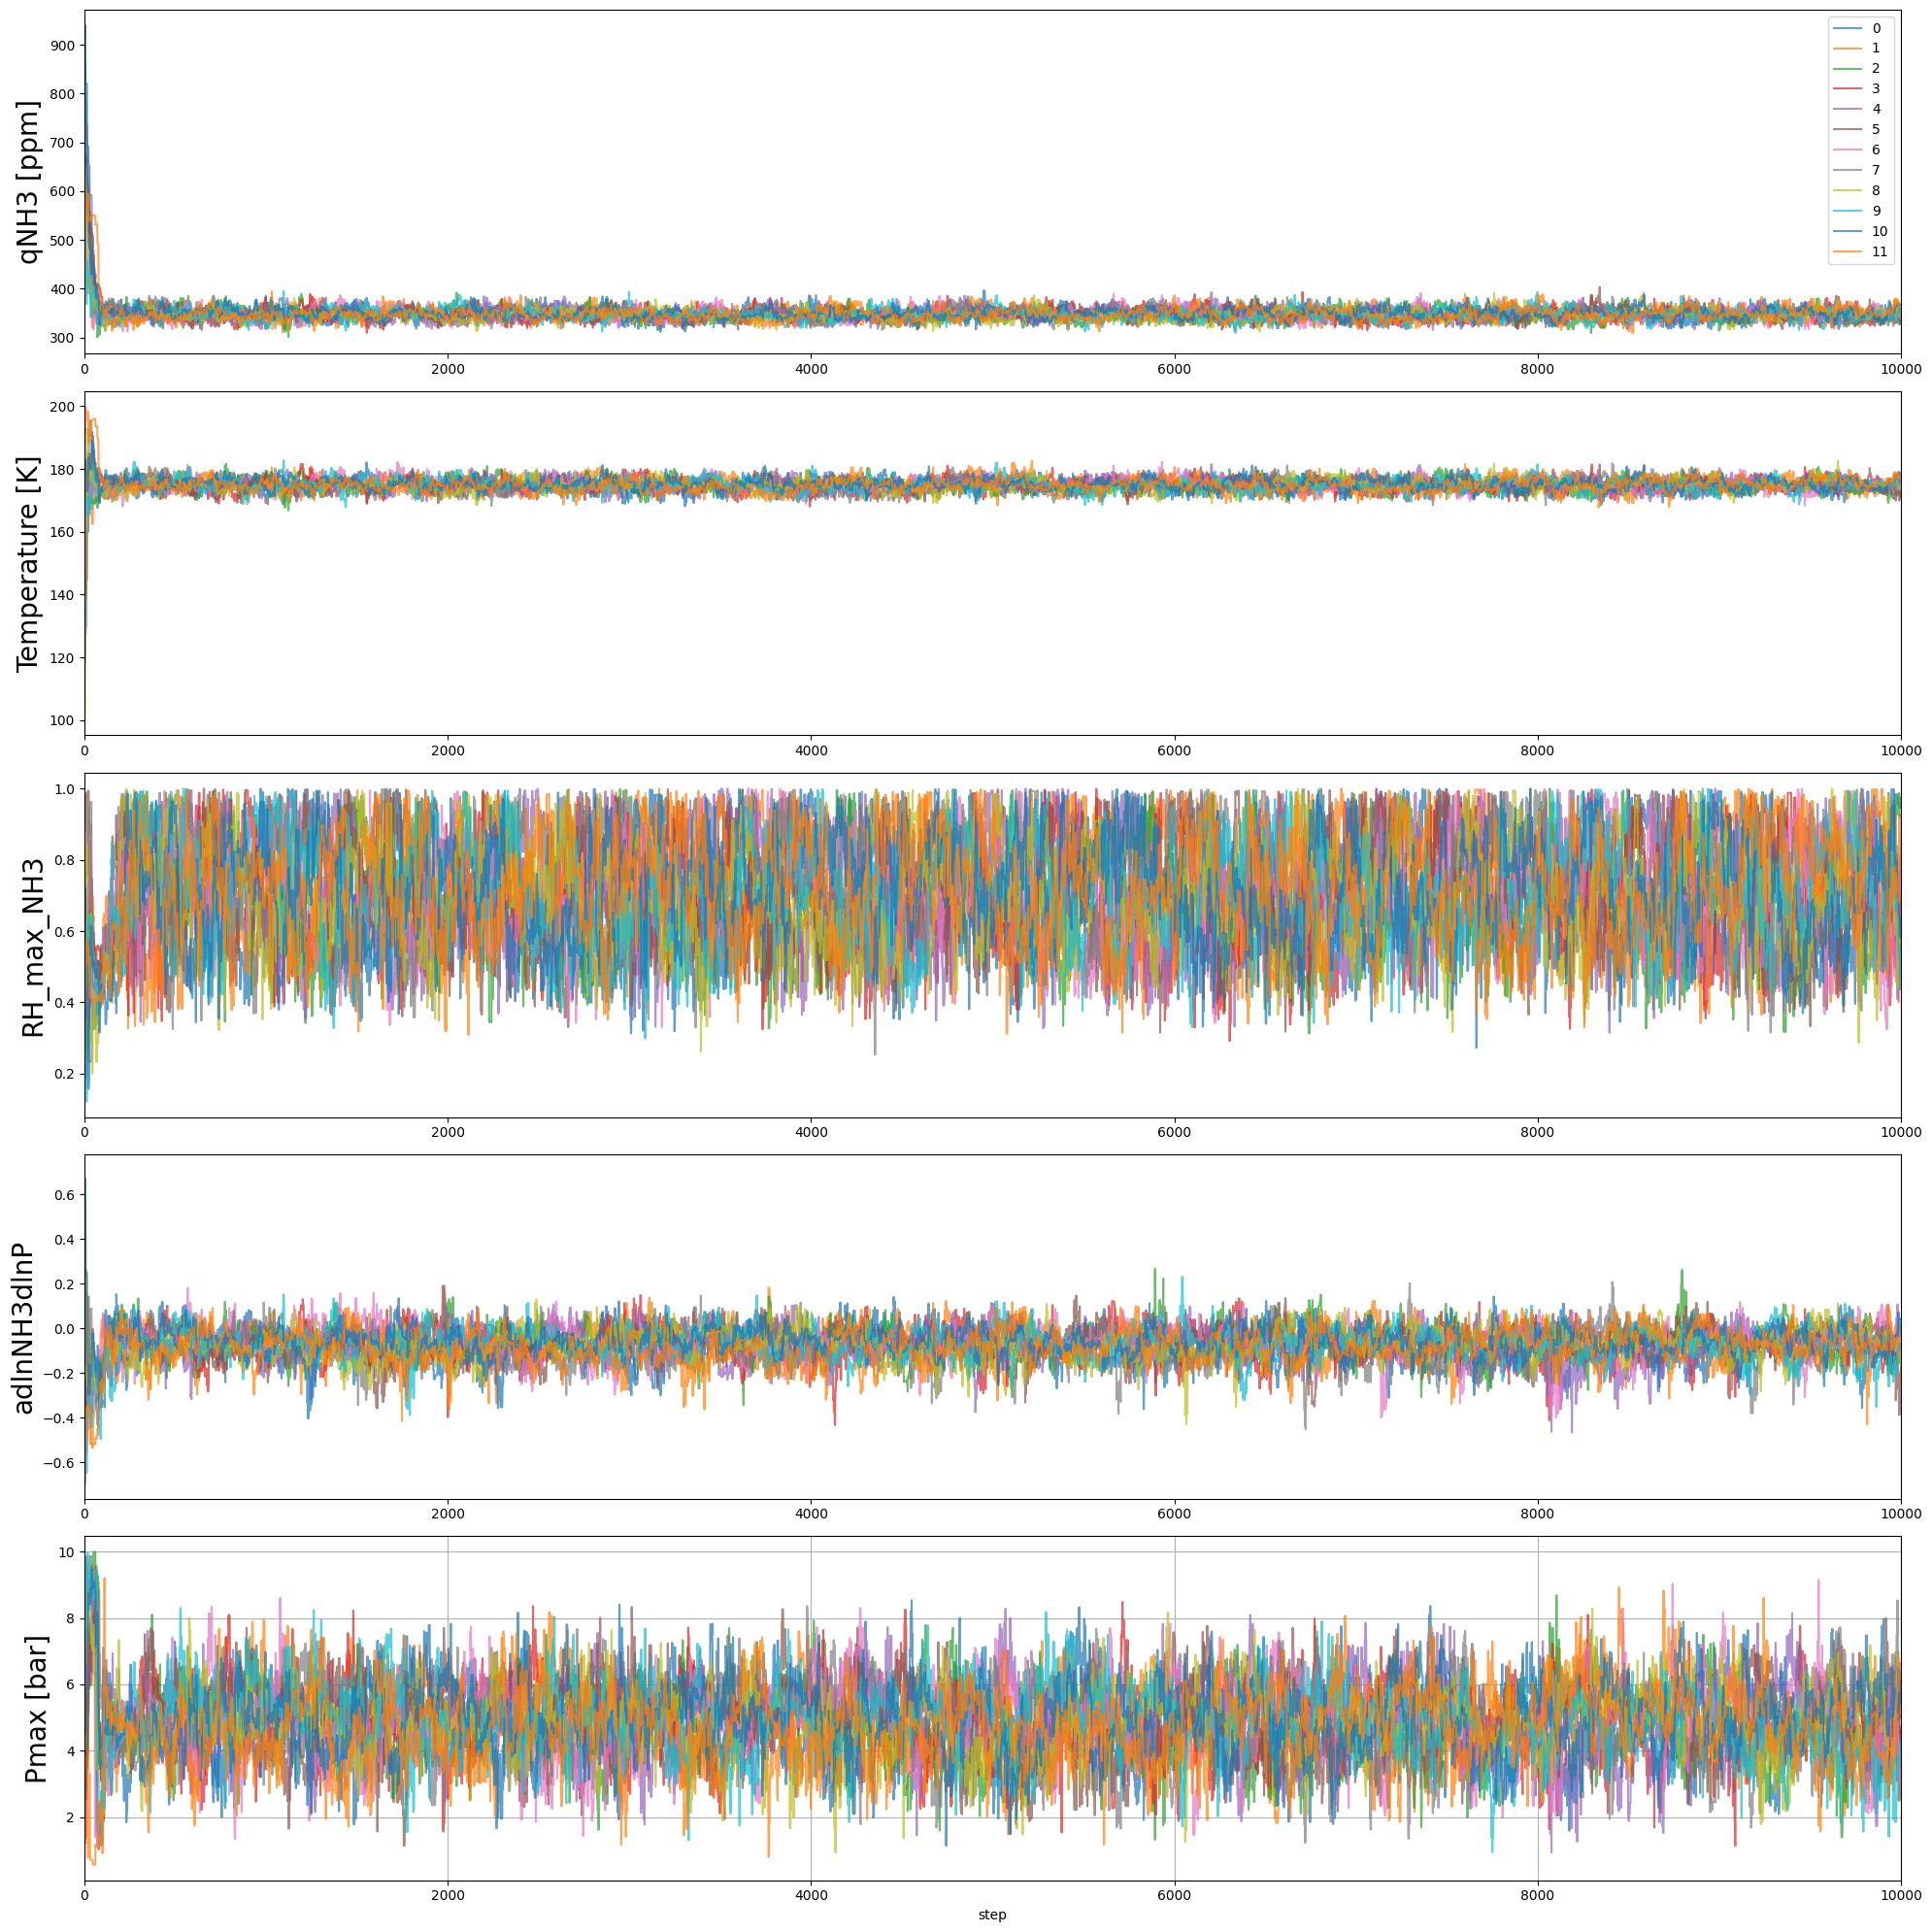

In [5]:
fig, ax = plt.subplots(ndim, 1, figsize=(20, 20))
for i in range(ndim):
    for iw in range(12):
        ax[i].plot(range(nstep), chain[:, iw, i],label=iw, alpha=0.7)
        ax[i].set_ylabel(labels[i],fontsize=20)
        ax[i].set_xlim([0, nstep])
ax[0].legend()
ax[ndim-1].set_xlabel("step")
plt.tight_layout()
plt.grid(True)
plt.show()

In [6]:
import corner
flattened_chain = chain[3000:,:,:].reshape(-1,5)


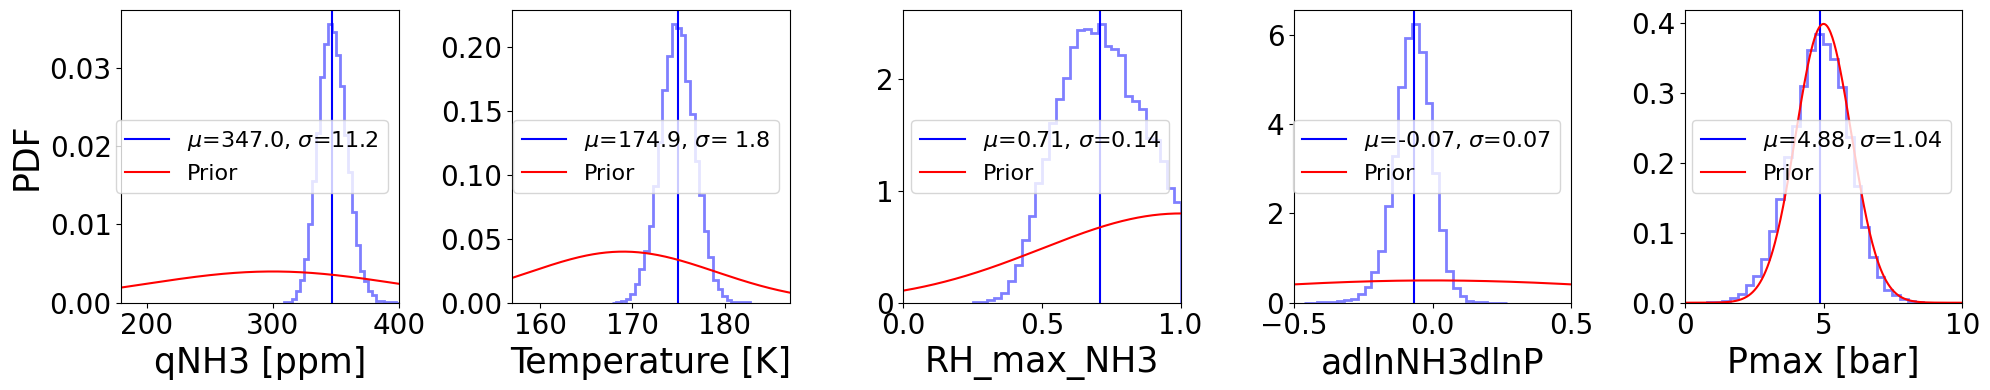

In [7]:

import statistics

# Create the corner plot
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

minx=[180,157,0,-0.5,0]
maxx=[400,187,1,0.5,10]

for i in range(5):
    
    # ax[i, i].hist(flattened_chain[:, i], bins=30, color="blue", alpha=0.7, density=True)
    ax[i].hist(flattened_chain[:, i], bins=30, color="blue", alpha=0.5, density=True, histtype='step', linewidth=2)
    # ax[i].hist(flattened_chain[:, i], bins=30, color="blue", alpha=0.5, density=True)
    ax[i].tick_params(axis='both', labelsize=20)
    # ax[i, i].set_xlabel(labels[i],fontsize=20)
    ax[i].set_xlabel(labels[i],fontsize=25)
    ax[0].set_ylabel("PDF",fontsize=25)
    ax[i].set_xlim(minx[i], maxx[i])

    counts, bins = np.histogram(flattened_chain[:, i], bins=30)

    # Find the peak value (the bin with the maximum count)
    peak_index = np.argmax(counts)
    peak_value = (bins[peak_index]+bins[peak_index+1])/2.
    # peak_value = bins[peak_index]


    means = np.percentile(flattened_chain[:, i], 50)
    stdev = np.std(flattened_chain[:, i])

    # ax[i, i].axvline(means,color="b",linestyle="--",label=f"posterior: ({means:6.2f}, {stdev:5.2f})")
    if i in (0,1):
        ax[i].axvline(means,color="b",linestyle="-",label=rf"$\mu$={means:4.1f}, $\sigma$={stdev:4.1f}")    
    else:
        ax[i].axvline(means,color="b",linestyle="-",label=rf"$\mu$={means:4.2f}, $\sigma$={stdev:4.2f}")
    

    # Plot prior distribution
    mean, stddev = [(300, 100), (169, 10), (1.0,0.5), (0,0.8),(5.0,1.)][i]
    x = np.linspace(minx[i], maxx[i], 300)

    prior = norm.pdf(x, mean, stddev)
    # ax[i, i].plot(x, prior, color="red", linestyle="--", label="Prior")
    ax[i].plot(x, prior, color="red", linestyle="-", label="Prior")
    ax[i].legend(fontsize=16)


# Show the plot
plt.tight_layout()
# Show the plot
plt.show()

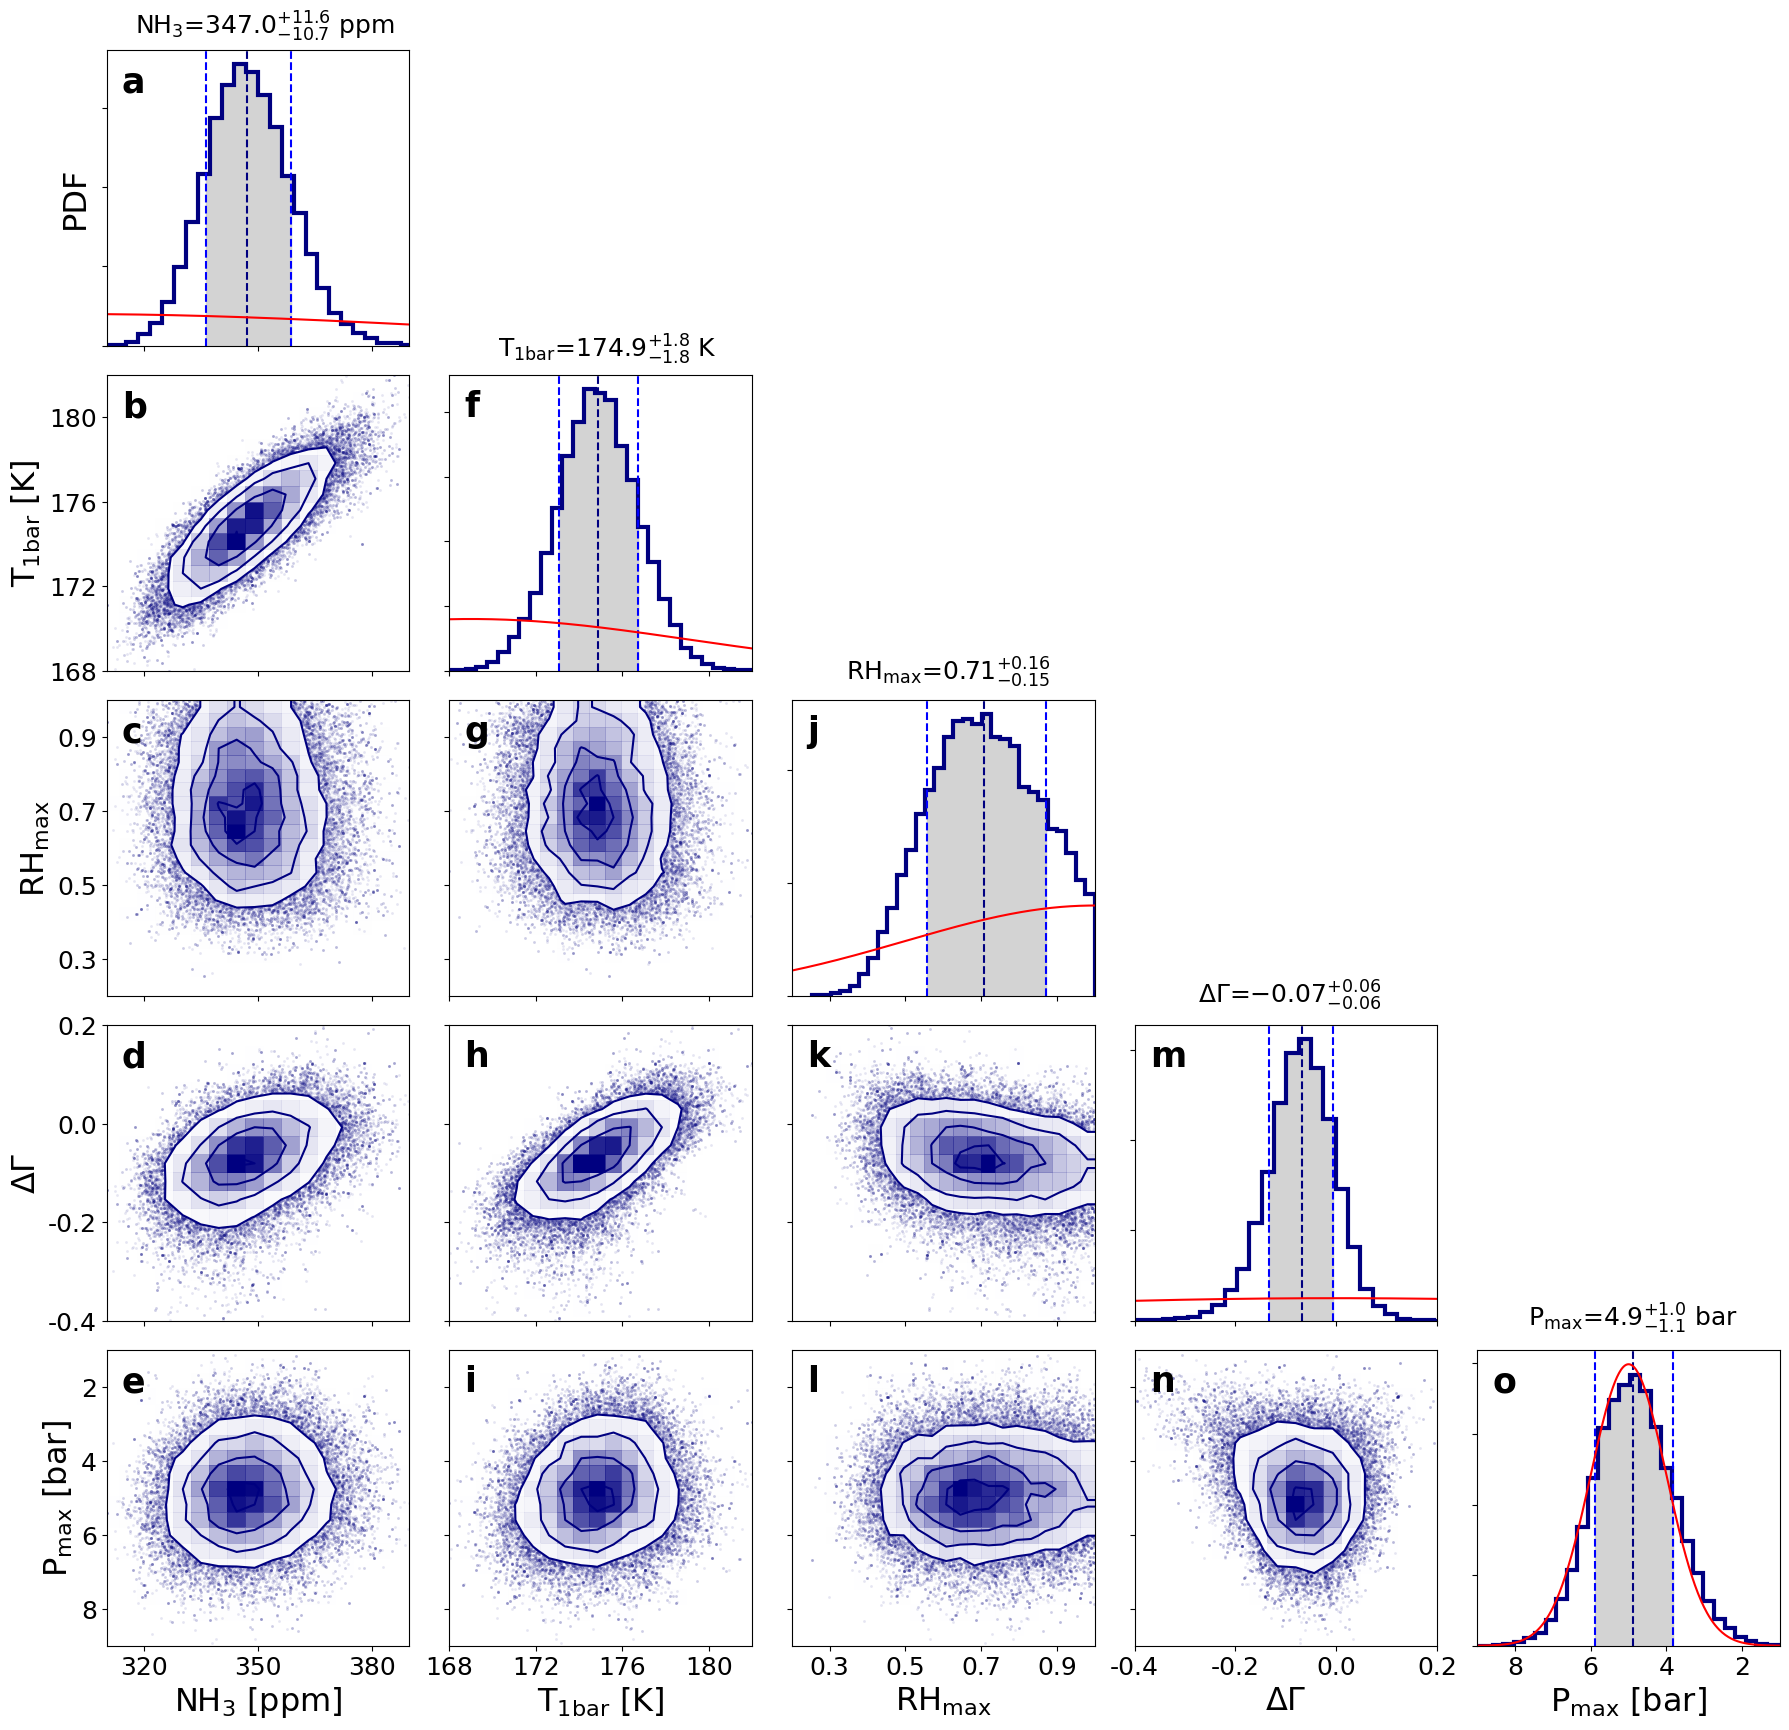

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import corner

# labels=[r"$xNH3$ [ppm]", r"$T_{1bar}$ [K]", r"$RH_{max}$",r"$\Delta\frac{dlnNH3}{dlnP}$",r"$P_{max}$ [bar]"]
labels=[r"NH$_3$", r"T$_{1\text{bar}}$", r"RH$_\text{max}$",r"$\Delta\Gamma$",r"P$_\text{max}$"]
units=[" [ppm]", " [K]","",""," [bar]"]
unit=["ppm", "K","","","bar"]

fig, ax = plt.subplots(5, 5, figsize=(18, 17))

minx = [310, 168, 0.2, -0.4, 9]
maxx = [390, 182, 1, 0.2, 1]

ticks=[[320,350,380],
       [168,172,176,180],
       [0.3,0.5,0.7,0.9],
       [-0.4,-0.2,0.0,0.2],
       [8,6,4,2]
       ]

ip=0
for i in range(5):
    for j in range(i,5):
        if i!=j:
            ax[i,j].axis('off')
            corner.hist2d(flattened_chain[:, i], flattened_chain[:, j], ax=ax[j, i], color="navy")

        ip+=1
        ax[j,i].text(0.05, 0.95, chr(96+ip), transform=ax[j,i].transAxes, fontsize=25, fontweight='bold', va='top', ha='left')

        ax[j,i].tick_params(axis='x', labelsize=18)
        ax[j,i].tick_params(axis='y', labelsize=18)

        ax[j,i].set_xlim(minx[i],maxx[i])
        if i!=j:
            ax[j,i].set_ylim(minx[j],maxx[j])

        if j==4:
            ax[j,i].set_xlabel(labels[i]+units[i], fontsize=23)
        else:
            ax[j,i].set_xlabel("")
        if i==0 and i!=j:
            ax[j,i].set_ylabel(labels[j]+units[j], fontsize=23)
        else:
            ax[j,i].set_ylabel("")            

        if i!=j:
            ax[j,i].set_yticks(ticks[j])
        ax[j,i].set_xticks(ticks[i])    

        ax[j,i].set_xticklabels([])
        ax[j,i].set_yticklabels([])
        if j==4:
            ax[j,i].set_xticklabels(ticks[i])
        if i==0 and i!=j:
            ax[j,i].set_yticklabels(ticks[j])
    ax[0,0].set_ylabel("PDF", fontsize=23)

    ## PDF for diagnal subplots
    ax[i,i].hist(flattened_chain[:, i], bins=30, color="Navy", alpha=1, histtype='step', linewidth=3, density=True)

    mmy = np.percentile(flattened_chain[:, i], 50)
    lowery = np.percentile(flattened_chain[:, i], 16)
    uppery = np.percentile(flattened_chain[:, i], 84)
    ## reflines
    ax[i,i].axvline(mmy,color="navy",linestyle="--")    
    ax[i,i].axvline(lowery,color="b",linestyle="--")    
    ax[i,i].axvline(uppery,color="b",linestyle="--")    

    # Plot prior distribution
    mean, stddev = [(300, 100), (169, 10), (1.0,0.5), (0,0.8),(5.0,1.)][i]
    x = np.linspace(minx[i], maxx[i], 300)
    prior = norm.pdf(x, mean, stddev)
    ax[i,i].plot(x, prior, color="red", linestyle="-")

    ## show posteriors over head
    teex=fr"{labels[i]}=${mmy:.1f}_{{{lowery-mmy:.1f}}}^{{+{uppery-mmy:.1f}}}$ {unit[i]}"
    if i==3 or i==2:
        teex=fr"{labels[i]}=${mmy:.2f}_{{{lowery-mmy:.2f}}}^{{+{uppery-mmy:.2f}}}$ {unit[i]}"
    fig.text(0.15+i*0.95/5., 1.015-(i*0.19), teex, ha='center', va='top', fontsize=18)

    # Calculate histogram data
    counts, bin_edges = np.histogram(flattened_chain[:, i], bins=30, density=True)

    for ii in range(len(counts)):
        if bin_edges[ii]<=(lowery) and  bin_edges[ii+1]>=(lowery):
            ax[i,i].fill_between([lowery,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(uppery) and  bin_edges[ii+1]>=(uppery):
            ax[i,i].fill_between([bin_edges[ii],uppery], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(lowery) and  bin_edges[ii+1]<=(uppery):
            ax[i,i].fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")
                

# Show the plot
plt.tight_layout()
# plt.savefig("Ext_MCMC_dry_corners.pdf", dpi=300,bbox_inches='tight')



/tmp/ipykernel_1554972/3395771984.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  original_cmap = cm.get_cmap('bwr')


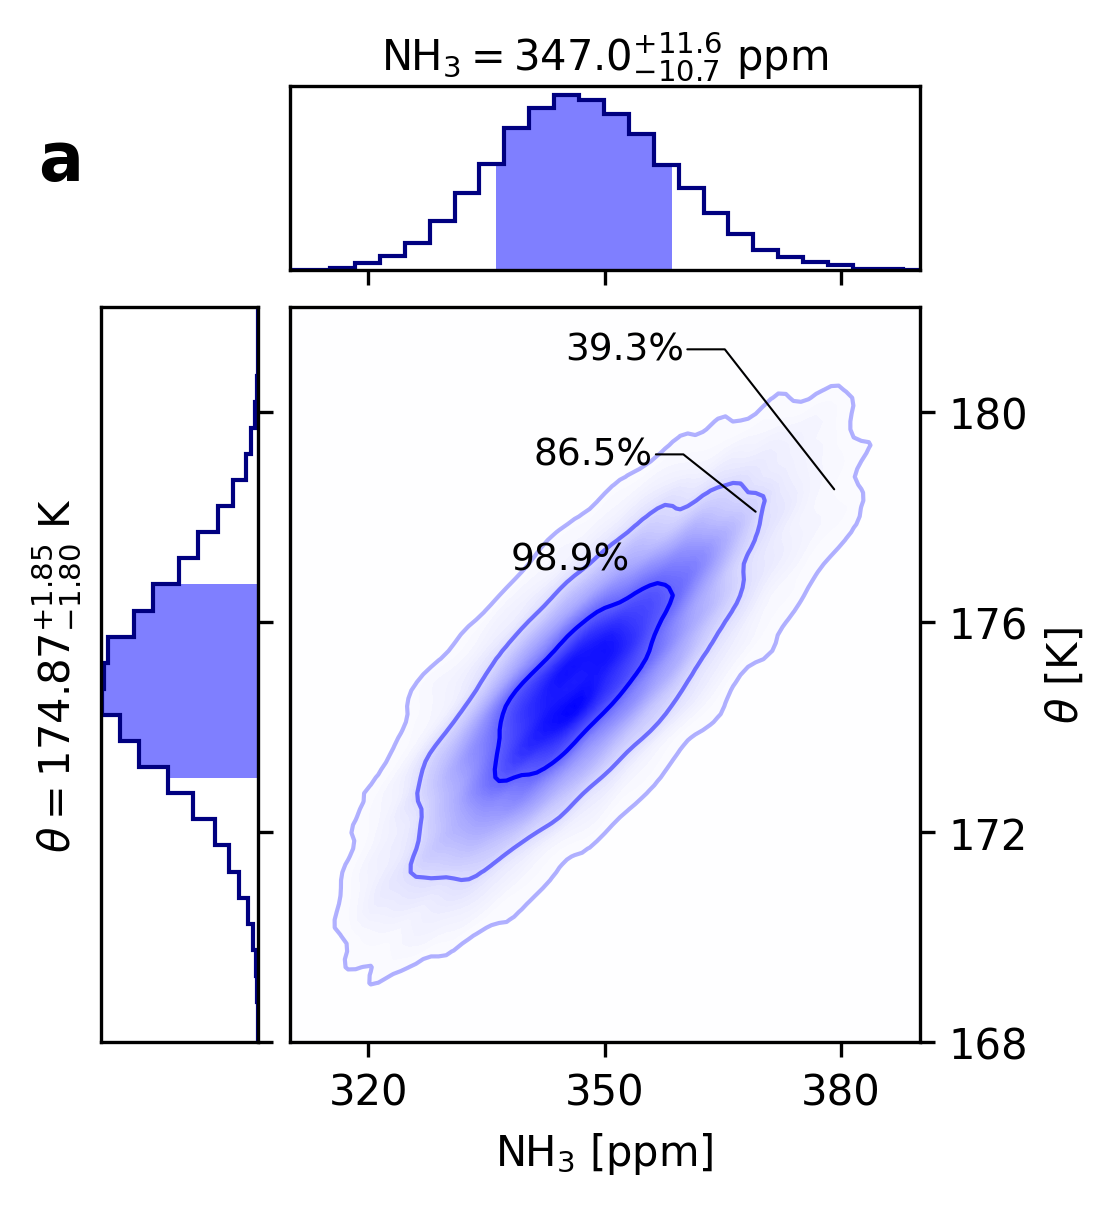

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import cm

x=flattened_chain[:, 0]
y=flattened_chain[:, 1]

# Calculate the 16th and 84th percentiles
mmx = np.percentile(x, 50)
lowerx = np.percentile(x, 16)
upperx = np.percentile(x, 84)

mmy = np.percentile(y, 50)
lowery = np.percentile(y, 16)
uppery = np.percentile(y, 84)

def demo_con_style(ax, text, theta1, theta2, linecolor, connectionstyle):
    x1, y1 = theta1
    x2, y2 = theta2

    # ax.plot([x1, x2], [y1, y2], ".")
    ax.annotate(text,
                xy=(x1, y1), xycoords='data',
                xytext=(x2, y2), textcoords='data',fontsize=9,
                arrowprops=dict(arrowstyle="-", color=linecolor,linewidth=0.5,
                                shrinkA=15, shrinkB=2,
                                patchA=None, patchB=None,
                                connectionstyle=connectionstyle,
                                ),
                )

def joint_hist(x, y, ax, ax_histx, ax_histy):
    # Disable labels and ticks on the appropriate sides
    ax_histx.tick_params(axis="x", labelbottom=False, labelleft=False, left=False)
    ax_histx.tick_params(axis="y", labelleft=False, left=False)

    ax_histy.tick_params(axis="y", labelleft=False, left=False, labelright=False, right=True)
    ax_histy.tick_params(axis="x", labelbottom=False, bottom=False)

    ax.tick_params(axis="y", labelleft=False, left=False, labelright=True, right=True)



    # Create grid for contour plot
    x_grid = np.linspace(np.min(x), np.max(x), 100)
    y_grid = np.linspace(np.min(y), np.max(y), 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = gaussian_kde(np.vstack([x, y]))(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    # Create a custom colormap using the first half of 'bwr_r'
    original_cmap = cm.get_cmap('bwr')
    custom_cmap = original_cmap(np.linspace(0.5, 0, 256))  # Extract the first half
    custom_cmap = cm.colors.ListedColormap(custom_cmap)

    # Plot contours using the custom colormap
    cont = ax.contourf(X, Y, Z, levels=100, cmap=custom_cmap, alpha=1)

    X, Y = np.meshgrid(x_grid, y_grid)
    kde = gaussian_kde([x, y])
    mean = [np.mean(x), np.mean(y)]
    cov = np.cov(x, y)

    from scipy.stats import multivariate_normal
    levels = [multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.6065306597,  # ~1 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.1353352832,  # ~2 std dev
            multivariate_normal.pdf(mean, mean=mean, cov=cov) * 0.01110899654, # ~3 std dev
            ] 
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    CS = ax.contour(X, Y,Z, levels=[levels[0],],  colors=('b',), linewidths=1, alpha=1)
    CS = ax.contour(X, Y,Z, levels=[levels[1],],  colors=('b',), linewidths=1, alpha=0.5)
    CS = ax.contour(X, Y,Z, levels=[levels[2],],  colors=('b',), linewidths=1, alpha=0.3)
    # CS = ax.contour(X, Y,Z, levels=levels[::-1],  colors=((1, 0, 0,1), (1, 0, 0,0.7), (1, 0, 0, 0.5)), linewidths=2)


    demo_con_style(ax, "39.3%",  [379.8,178.4], [345,181], "k","arc,angleA=0,angleB=-90,armA=100,rad=0")
    demo_con_style(ax, "86.5%", [370,178], [341,179], "k","arc,angleA=0,angleB=-90,armA=90,rad=0")
    ax.text(338,177, "98.9%",fontsize=9)




    ax_histx.hist(x, bins=30, density=True, color="Navy", alpha=1, histtype='step')
    ax_histy.hist(y, bins=30, density=True, color='Navy', alpha=1, histtype='step', orientation='horizontal')
    ax_histy.invert_xaxis()
    ax_histy.set_xlim(0.22,0)


    means = np.mean(x)
    stdev = np.std(x)
    counts, bin_edges = np.histogram(x, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histx.fill_between([means - stdev,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],means + stdev], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histx.fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],  color='blue', alpha=0.5,linewidth=0)

    means = np.mean(y)
    stdev = np.std(y)
    counts, bin_edges = np.histogram(y, bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax_histy.fill_between([counts[ii],0],means - stdev,bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],means + stdev, color='blue', alpha=0.5,linewidth=0)
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax_histy.fill_between([counts[ii],0],bin_edges[ii],bin_edges[ii+1], color='blue', alpha=0.5,linewidth=0)


# Create a figure with the constrained layout
fig = plt.figure(figsize=(14,14),dpi=300)
# fig = plt.figure(layout='constrained')

# Create the main scatter plot axes
ax = fig.add_gridspec(top=0.75, left=0.75).subplots()
# ax.set(aspect=1)
ax.set(aspect=6.67) 
# Create marginal histograms for x and y axes
ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
ax_histy = ax.inset_axes([-0.3, 0, 0.25, 1], sharey=ax)

ax.set_xlim(310,390)
ax.set_ylim(168,182)

ax.set_yticks([168, 172,176,180])
ax.set_xticks([320,350,380])

ax.set_xlabel(r'$\text{NH}_3$ [ppm]')
ax.set_ylabel(r'$\theta$ [K]')
ax.yaxis.set_label_position("right")


# ax_histx.axvline(x=lowerx, color='black', linestyle='--')
# ax_histx.axvline(x=upperx, color='black', linestyle='--')

# ax_histy.axhline(y=lowery, color='black', linestyle='--')
# ax_histy.axhline(y=uppery, color='black', linestyle='--')

ax_histx.set_xlabel(rf"NH$_3={mmx:.1f}_{{{lowerx-mmx:.1f}}}^{{+{upperx-mmx:.1f}}}$ ppm")
ax_histy.set_ylabel(rf"$\theta={mmy:.2f}_{{{lowery-mmy:.2f}}}^{{+{uppery-mmy:.2f}}}$ K")

ax_histx.xaxis.set_label_position("top")
ax_histy.yaxis.set_label_position("left")


## crossing
# ax.axhline(y=mmy, linestyle="--",color='red', linewidth=1)
# ax.axvline(x=mmx, linestyle="--",color='blue', linewidth=1)
# ax_histy.axhline(y=169,linestyle="--", color='red', linewidth=1)
# ax_histx.axvline(x=350,linestyle="--", color='red', linewidth=1)

# ax_histy.axhline(y=166,linestyle="--", color='green', linewidth=1)
# ax_histx.axvline(x=375,linestyle="--", color='green', linewidth=1)


# ax.plot((350,169),'ro')
# ax.plot((375,166),'go')

# Draw the density plot and marginal histograms
joint_hist(x, y, ax, ax_histx, ax_histy)
fig.text(0.69, 0.56, "a", fontsize=16, fontweight='bold', va='top', ha='left')

plt.show()
